# ML-10 — Content Action Playbook

**Lane:** Refresh / Content Opportunity Scoring.

This notebook converts the validated model into a practical, non-production review queue. It ranks what a content analyst should inspect first, explains why each item appears, and sets explicit human-review and no-automation boundaries.

The scores are observed decision-support signals from the public starter snapshot. They do not estimate causal lift, predict Google's algorithm, or authorize automatic content changes.

> Repository guidance used: `writing-honest-claims` + `flyrank/flyrank-data`.

## 1. Ranked actions and reason codes

### How ranking works

The candidate population remains frozen from Week 4: at least 300 impressions, measured position 1–20, and CTR below 0.50 percentage points. The same honest Week-5 feature set is used.

To avoid in-sample ranking, every page receives a Random Forest score from a fold where its entire pseudonymized client was held out. Five-fold `GroupKFold` gives an out-of-fold score for all candidates. The final **priority score** combines:

- 70% model-score percentile: observed similarity to decline cases;
- 30% log-impression percentile: measured exposure at stake.

This is a relative review priority from 0–100, not an expected percentage lift.

### Archetype → action map

| Archetype | Reason code | Human-reviewed action | Why it is useful |
|---|---|---|---|
| Mature + stale | `mature_stale_visible` | Audit and refresh outdated sections | Connects the paper's measured decay/refresh insight to a review—not a causal promise |
| Thin + visible | `thin_visible_gap` | Inspect intent and expand missing coverage | Uses existing visibility to focus effort; never pads for length |
| Page-one low CTR | `page1_low_ctr` | Review query mix, title, metadata, and intent | Looks for under-captured clicks where visibility already exists |
| Striking-distance low CTR | `striking_low_ctr` | Improve relevance and internal support | Reviews pages close to page one without promising rank movement |
| Other visible low CTR | `visible_low_ctr_monitor` | Monitor and diagnose before editing | Keeps ambiguous cases in a lower-confidence review lane |

In [1]:
from pathlib import Path
import json
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
repo_root = Path.cwd()
while not (repo_root / "data" / "raw" / "content_refresh_anonymized.csv").exists():
    if repo_root == repo_root.parent:
        raise FileNotFoundError("Could not locate the starter dataset.")
    repo_root = repo_root.parent

df = pd.read_csv(repo_root / "data" / "raw" / "content_refresh_anonymized.csv")
df["is_declining_proxy"] = df["trend_direction"].eq("down").astype("int8")

eligible = (
    df["impressions_90d"].ge(300)
    & df["avg_position"].gt(0)
    & df["avg_position"].le(20)
    & df["ctr"].lt(0.50)
)
frame = df.loc[eligible].copy().reset_index(drop=True)
target = "is_declining_proxy"

numeric_features = [
    "search_volume", "competition", "cpc", "word_count",
    "content_age_days", "days_since_last_update",
    "impressions_90d", "clicks_90d", "sessions_90d",
    "days_with_impressions", "days_with_sessions",
    "ctr", "avg_position", "engagement_rate",
]
categorical_features = [
    "content_type", "main_intent", "competition_level", "freshness_tier",
]
feature_columns = numeric_features + categorical_features

def build_pipeline():
    preprocessor = ColumnTransformer([
        ("numeric", Pipeline([
            ("impute", SimpleImputer(strategy="median", add_indicator=True)),
            ("scale", StandardScaler()),
        ]), numeric_features),
        ("categorical", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("one_hot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ])
    model = RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=20,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1,
    )
    return Pipeline([("preprocess", preprocessor), ("model", model)])

group_cv = GroupKFold(n_splits=5)
oof_score = np.full(len(frame), np.nan)
fold_receipts = []

for fold, (train_idx, test_idx) in enumerate(
    group_cv.split(frame, frame[target], groups=frame["client_id"]), start=1
):
    pipeline = build_pipeline()
    train = frame.iloc[train_idx]
    test = frame.iloc[test_idx]
    pipeline.fit(train[feature_columns], train[target])
    oof_score[test_idx] = pipeline.predict_proba(test[feature_columns])[:, 1]
    overlap = len(set(train["client_id"]) & set(test["client_id"]))
    fold_receipts.append({
        "fold": fold,
        "train_rows": int(len(train)),
        "test_rows": int(len(test)),
        "test_clients": int(test["client_id"].nunique()),
        "client_overlap": overlap,
    })

assert not np.isnan(oof_score).any()
assert all(r["client_overlap"] == 0 for r in fold_receipts)

frame["model_score_oof"] = oof_score
frame["model_score_percentile"] = frame["model_score_oof"].rank(pct=True)
frame["impact_percentile"] = np.log1p(frame["impressions_90d"]).rank(pct=True)
frame["priority_score"] = 100 * (
    0.70 * frame["model_score_percentile"]
    + 0.30 * frame["impact_percentile"]
)

def assign_archetype(row):
    if row["content_age_days"] >= 270 and row["days_since_last_update"] >= 91:
        return "Mature + stale"
    if pd.notna(row["word_count"]) and row["word_count"] < 2000:
        return "Thin + visible"
    if row["avg_position"] <= 10:
        return "Page-one low CTR"
    if row["avg_position"] <= 20:
        return "Striking-distance low CTR"
    return "Other visible low CTR"

action_map = {
    "Mature + stale": (
        "mature_stale_visible",
        "audit_refresh_outdated_sections",
        "Review facts, examples, coverage, and current intent; refresh only confirmed gaps.",
        "medium",
    ),
    "Thin + visible": (
        "thin_visible_gap",
        "inspect_and_expand_missing_coverage",
        "Check query intent and missing subtopics; expand only when useful, never for word count alone.",
        "high",
    ),
    "Page-one low CTR": (
        "page1_low_ctr",
        "review_click_capture",
        "Inspect query mix, SERP context, title, metadata, and intent before proposing a change.",
        "low",
    ),
    "Striking-distance low CTR": (
        "striking_low_ctr",
        "review_relevance_and_internal_support",
        "Check intent fit, internal links, and content gaps before changing the page.",
        "medium",
    ),
    "Other visible low CTR": (
        "visible_low_ctr_monitor",
        "monitor_and_diagnose",
        "Collect query-level and current-page evidence before any edit.",
        "low",
    ),
}

frame["archetype"] = frame.apply(assign_archetype, axis=1)
frame[["reason_code", "action_label", "review_instruction", "cost_tier"]] = (
    frame["archetype"].apply(lambda x: pd.Series(action_map[x]))
)
frame["value_tier"] = pd.cut(
    frame["impressions_90d"],
    bins=[0, 3_000, 30_000, np.inf],
    labels=["moderate", "high", "very_high"],
    right=False,
).astype(str)

queue = frame.sort_values(
    ["priority_score", "impressions_90d", "content_id"],
    ascending=[False, False, True],
    kind="stable",
).reset_index(drop=True)
queue.insert(0, "rank", np.arange(1, len(queue) + 1))

oof_auc = roc_auc_score(frame[target], frame["model_score_oof"])
oof_ap = average_precision_score(frame[target], frame["model_score_oof"])
oof_p50 = float(queue.head(50)[target].mean())

print("Ranked candidates:", f"{len(queue):,}")
print("Five-fold grouped client overlap:", sum(r["client_overlap"] for r in fold_receipts))
print("OOF base rate:", f"{frame[target].mean():.1%}")
print("OOF ROC AUC:", f"{oof_auc:.3f}")
print("OOF average precision:", f"{oof_ap:.3f}")
print("OOF Precision@50:", f"{oof_p50:.1%}")
display(pd.DataFrame(fold_receipts))

Ranked candidates: 10,730
Five-fold grouped client overlap: 0
OOF base rate: 63.5%
OOF ROC AUC: 0.635
OOF average precision: 0.740
OOF Precision@50: 82.0%


,fold,train_rows,test_rows,test_clients,client_overlap
0,1,6615,4115,1,0
1,2,9082,1648,6,0
2,3,9083,1647,7,0
3,4,9082,1648,8,0
4,5,9058,1672,6,0


In [2]:
top_columns = [
    "rank", "content_id", "priority_score", "model_score_oof",
    "archetype", "reason_code", "action_label", "value_tier",
    "cost_tier", "impressions_90d", "ctr", "avg_position",
    "days_since_last_update", "review_instruction",
]
print("Top 20 human-review actions:")
display(queue[top_columns].head(20).round({
    "priority_score": 1,
    "model_score_oof": 3,
    "ctr": 3,
    "avg_position": 1,
}))

action_summary = (
    queue.groupby(
        ["archetype", "reason_code", "action_label", "cost_tier"],
        observed=True,
    )
    .agg(
        n=("content_id", "size"),
        median_priority=("priority_score", "median"),
        median_impressions=("impressions_90d", "median"),
    )
    .reset_index()
    .sort_values("median_priority", ascending=False)
)
display(action_summary.round({"median_priority": 1, "median_impressions": 0}))

Top 20 human-review actions:


,rank,content_id,priority_score,model_score_oof,archetype,reason_code,action_label,value_tier,cost_tier,impressions_90d,ctr,avg_position,days_since_last_update,review_instruction
0,1,content_339b357d04c7,92.2,0.699,Page-one low CTR,page1_low_ctr,review_click_capture,very_high,low,46879,0.01,3.7,15,"Inspect query mix, SERP context, title, metada..."
1,2,content_c6999f7eb5fb,91.5,0.715,Page-one low CTR,page1_low_ctr,review_click_capture,high,low,17790,0.01,8.8,20,"Inspect query mix, SERP context, title, metada..."
2,3,content_733815afb7a5,90.9,0.779,Page-one low CTR,page1_low_ctr,review_click_capture,high,low,7095,0.04,2.6,20,"Inspect query mix, SERP context, title, metada..."
3,4,content_c82bc0c24241,90.8,0.718,Page-one low CTR,page1_low_ctr,review_click_capture,high,low,13676,0.00,4.3,8,"Inspect query mix, SERP context, title, metada..."
4,5,content_954cc45bd437,90.0,0.705,Page-one low CTR,page1_low_ctr,review_click_capture,high,low,15439,0.04,1.5,7,"Inspect query mix, SERP context, title, metada..."
5,6,content_4d2a523dfda1,89.9,0.746,Page-one low CTR,page1_low_ctr,review_click_capture,high,low,7830,0.10,2.4,20,"Inspect query mix, SERP context, title, metada..."
6,7,content_d6e1bbb4a996,89.1,0.797,Page-one low CTR,page1_low_ctr,review_click_capture,high,low,4955,0.00,3.9,20,"Inspect query mix, SERP context, title, metada..."
7,8,content_186489efe6f4,88.9,0.797,Page-one low CTR,page1_low_ctr,review_click_capture,high,low,4792,0.06,2.3,104,"Inspect query mix, SERP context, title, metada..."
8,9,content_134631e65b9e,88.9,0.830,Page-one low CTR,page1_low_ctr,review_click_capture,high,low,4417,0.00,1.5,20,"Inspect query mix, SERP context, title, metada..."
9,10,content_66458ac1b739,88.8,0.742,Thin + visible,thin_visible_gap,inspect_and_expand_missing_coverage,high,high,6822,0.03,2.9,102,Check query intent and missing subtopics; expa...


,archetype,reason_code,action_label,cost_tier,n,median_priority,median_impressions
3,Thin + visible,thin_visible_gap,inspect_and_expand_missing_coverage,high,547,54.7,993.0
2,Striking-distance low CTR,striking_low_ctr,review_relevance_and_internal_support,medium,3430,51.7,1759.0
1,Page-one low CTR,page1_low_ctr,review_click_capture,low,4981,48.0,4078.0
0,Mature + stale,mature_stale_visible,audit_refresh_outdated_sections,medium,1772,45.3,2524.0


### Decay/refresh insight, stated carefully

The paper observed substantially stronger measured outcomes among recently refreshed mature pages than among stale mature pages. In this playbook, that finding becomes a reason to **audit mature stale pages earlier**, not a promise that refreshing them will cause recovery.

Selection matters: teams may choose already-promising pages to refresh, and the starter snapshot cannot separate that choice from the measured outcome. The `mature_stale_visible` reason code therefore triggers a human check of prior visibility, current accuracy, intent, and business value before work is approved.

## 2. Intended use and limits

**Intended user:** a content strategist, SEO analyst, or editor planning a weekly review batch.

**Decision supported:** which already-visible pages to inspect first and which diagnostic path to follow.

**Suggested cadence:** review the top 20–50 items weekly; approve, defer, or reject each recommendation with a short reason. The queue should never be treated as an automatic task list.

**Limits:**

- The public starter file is one 90-day snapshot. Its features overlap the windows used to define the observed decline proxy, so this is not a true future forecast.
- The Week-6 client-grouped holdout measured Precision@50 of 78%, ROC AUC 0.639, and a 55.4% base rate. These are directional validation results, not service-level guarantees.
- The model cannot see current page text, query mix, SERP features, seasonality, conversions, legal requirements, brand priorities, or whether a page changed after measurement.
- `model_score_oof` and `priority_score` are relative ranking signals, not calibrated decline probabilities or expected revenue.
- The queue contains pseudonymized content IDs and public-safe aggregates only.

In [3]:
intended_use = pd.DataFrame([
    {
        "stage": "1. Triage",
        "owner": "Analyst",
        "input": "Top 20-50 ranked rows",
        "output": "Review batch, not an edit list",
    },
    {
        "stage": "2. Diagnose",
        "owner": "Analyst + editor",
        "input": "Current page, query mix, trend, SERP and business context",
        "output": "Approve, defer, reject, or monitor",
    },
    {
        "stage": "3. Plan",
        "owner": "Editor/strategist",
        "input": "Confirmed gap and reason code",
        "output": "Scoped change with success measure",
    },
    {
        "stage": "4. Measure",
        "owner": "Analyst",
        "input": "Pre/post or matched comparison",
        "output": "Observed outcome and learning",
    },
])
display(intended_use)

,stage,owner,input,output
0,1. Triage,Analyst,Top 20-50 ranked rows,"Review batch, not an edit list"
1,2. Diagnose,Analyst + editor,"Current page, query mix, trend, SERP and busin...","Approve, defer, reject, or monitor"
2,3. Plan,Editor/strategist,Confirmed gap and reason code,Scoped change with success measure
3,4. Measure,Analyst,Pre/post or matched comparison,Observed outcome and learning


## 3. Human review and the no-go list

### Required review before any action

For every queued item, a person must check:

1. **Current state:** does the live content still match the measured snapshot?
2. **Query and intent:** is low CTR explained by branded, navigational, zero-click, mixed, or irrelevant queries?
3. **SERP context:** are features, ads, local results, or answer boxes changing click behavior?
4. **Business value:** is the page strategically or commercially worth the proposed effort?
5. **Content quality and accuracy:** is there a real gap, stale fact, weak structure, or mismatch?
6. **Overlap/cannibalization:** should pages be consolidated rather than independently edited?
7. **Risk:** does the page carry legal, medical, financial, contractual, localization, or brand sensitivity?
8. **Measurement plan:** what metric and follow-up window will show whether the approved change helped?

### What must NOT be automated

- publishing, rewriting, deleting, pruning, merging, redirecting, or changing canonical/indexing settings;
- changing titles or metadata without query and SERP review;
- treating model scores as probabilities, revenue forecasts, or proof of causal refresh impact;
- acting on sensitive or regulated content without the appropriate owner;
- exposing client identity, URLs, private queries, credentials, or raw exports;
- retraining on `trend_direction`, `trend_pct`, recent comparison-window siblings, IDs, product flags, or prior system scores;
- evaluating edits on the same window used to choose them.

In [4]:
review_decisions = pd.DataFrame([
    {
        "decision": "APPROVE",
        "minimum evidence": "Current gap confirmed; value exceeds cost; owner and follow-up metric assigned.",
    },
    {
        "decision": "DEFER",
        "minimum evidence": "Plausible opportunity, but timing, capacity, or evidence is incomplete.",
    },
    {
        "decision": "REJECT",
        "minimum evidence": "Recommendation contradicted by current query, page, SERP, risk, or business context.",
    },
    {
        "decision": "MONITOR",
        "minimum evidence": "Signal is ambiguous; collect another non-overlapping measurement window.",
    },
])
display(review_decisions)

cost_value_matrix = pd.DataFrame([
    {"value_tier": "very_high", "cost_tier": "low", "review_priority": "Review first"},
    {"value_tier": "very_high", "cost_tier": "medium/high", "review_priority": "Review early; scope carefully"},
    {"value_tier": "high", "cost_tier": "low/medium", "review_priority": "Normal weekly batch"},
    {"value_tier": "moderate", "cost_tier": "high", "review_priority": "Usually defer unless strategic"},
])
print("Cost/value thinking:")
display(cost_value_matrix)

,decision,minimum evidence
0,APPROVE,Current gap confirmed; value exceeds cost; own...
1,DEFER,"Plausible opportunity, but timing, capacity, o..."
2,REJECT,"Recommendation contradicted by current query, ..."
3,MONITOR,Signal is ambiguous; collect another non-overl...


Cost/value thinking:


,value_tier,cost_tier,review_priority
0,very_high,low,Review first
1,very_high,medium/high,Review early; scope carefully
2,high,low/medium,Normal weekly batch
3,moderate,high,Usually defer unless strategic


## 4. Monitoring and retrain triggers

This is a notebook playbook, not a production service. Monitoring is deliberately light and human-owned.

### Batch monitoring

- record how many of the top 50 were approved, rejected, deferred, or monitored;
- record rejection reasons so recurring false-positive patterns become new diagnostics;
- after a non-overlapping follow-up window, recompute Precision@50 against the same proxy definition;
- track candidate count, base rate, action mix, missingness, and score distribution.

### Pause/retrain triggers

- **Performance:** grouped or later-window Precision@50 falls below the frozen Week-4 baseline of 74%, or drops more than 10 percentage points from the validated 78%.
- **Population:** candidate volume changes by more than 30%, or the observed base rate shifts by more than 10 percentage points.
- **Data:** any key feature's missingness changes by more than 10 percentage points; a schema or metric definition changes; warehouse availability flags are not `IS TRUE`.
- **Behavior:** more than half of a reviewed top-50 batch is rejected for the same missing context.
- **Time:** reassess quarterly or after enough new, non-overlapping labeled outcomes exist.

Retraining alone is not the answer to a broken label, overlapping timeline, or changed business decision. Fix those first.

In [5]:
monitoring_plan = pd.DataFrame([
    {
        "signal": "Grouped/later-window Precision@50",
        "reference": "78% validated; 74% Week-4 baseline",
        "trigger": "<74% or >10pp drop",
        "response": "Pause queue; audit labels, drift, and errors before retraining",
    },
    {
        "signal": "Candidate volume",
        "reference": f"{len(queue):,} starter candidates",
        "trigger": ">30% change",
        "response": "Check data coverage, eligibility, and portfolio mix",
    },
    {
        "signal": "Observed base rate",
        "reference": f"{frame[target].mean():.1%} OOF population",
        "trigger": ">10pp shift",
        "response": "Revalidate thresholds and ranking metrics",
    },
    {
        "signal": "Feature missingness/schema",
        "reference": "Current notebook contract",
        "trigger": ">10pp missingness change or schema change",
        "response": "Stop scoring until preprocessing and availability are reviewed",
    },
    {
        "signal": "Human rejection pattern",
        "reference": "Top-50 review log",
        "trigger": ">50% same rejection reason",
        "response": "Add missing diagnostic or revise archetype rules",
    },
])
display(monitoring_plan)

,signal,reference,trigger,response
0,Grouped/later-window Precision@50,78% validated; 74% Week-4 baseline,<74% or >10pp drop,"Pause queue; audit labels, drift, and errors b..."
1,Candidate volume,"10,730 starter candidates",>30% change,"Check data coverage, eligibility, and portfoli..."
2,Observed base rate,63.5% OOF population,>10pp shift,Revalidate thresholds and ranking metrics
3,Feature missingness/schema,Current notebook contract,>10pp missingness change or schema change,Stop scoring until preprocessing and availabil...
4,Human rejection pattern,Top-50 review log,>50% same rejection reason,Add missing diagnostic or revise archetype rules


## 5. Exports for the paper

The notebook regenerates:

- `work/outputs/ranked_action_queue.csv` — full pseudonymized review queue; intentionally ignored by git;
- `work/figures/w07_action_mix.png` — aggregate paper-ready action-mix chart; committed;
- `work/outputs/w07_playbook_metrics.json` — commit-safe receipt tracing the paper's playbook numbers.

The chart reports aggregate counts only. No client identity, domain, URL, or private query is exported.

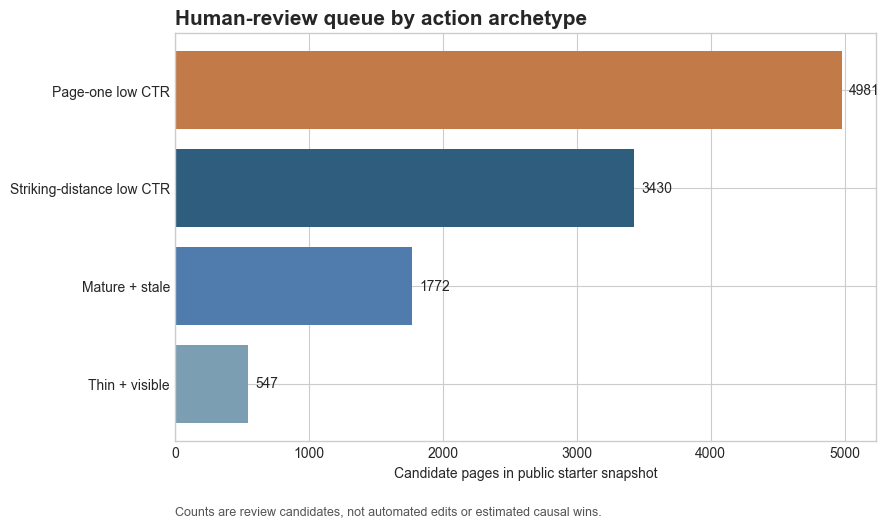

Wrote: work/outputs/ranked_action_queue.csv
Wrote: work/figures/w07_action_mix.png
Wrote: work/outputs/w07_playbook_metrics.json


,n
archetype,
Thin + visible,547
Mature + stale,1772
Striking-distance low CTR,3430
Page-one low CTR,4981


In [6]:
output_dir = repo_root / "work" / "outputs"
figure_dir = repo_root / "work" / "figures"
output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

queue_export_columns = [
    "rank", "content_id", "priority_score", "model_score_oof",
    "archetype", "reason_code", "action_label", "review_instruction",
    "value_tier", "cost_tier", "impressions_90d", "clicks_90d",
    "ctr", "avg_position", "content_age_days", "days_since_last_update",
]
queue_path = output_dir / "ranked_action_queue.csv"
queue[queue_export_columns].to_csv(queue_path, index=False)

action_counts = queue["archetype"].value_counts().sort_values()
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(9, 5.4))
colors = ["#7c9eb2", "#4f7cac", "#2f5d7e", "#c27b48", "#8a5a44"]
bars = ax.barh(action_counts.index, action_counts.values, color=colors[:len(action_counts)])
ax.set_title("Human-review queue by action archetype", loc="left", fontsize=15, weight="bold")
ax.set_xlabel("Candidate pages in public starter snapshot")
ax.set_ylabel("")
ax.bar_label(bars, padding=5, fmt="%.0f")
ax.text(
    0, -0.18,
    "Counts are review candidates, not automated edits or estimated causal wins.",
    transform=ax.transAxes, fontsize=9, color="#555555",
)
fig.tight_layout()
figure_path = figure_dir / "w07_action_mix.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

receipt = {
    "lane": "Refresh / Content Opportunity Scoring",
    "queue_rows": int(len(queue)),
    "candidate_definition": (
        "impressions_90d >= 300; 0 < avg_position <= 20; ctr < 0.50 percentage points"
    ),
    "scoring_design": "5-fold GroupKFold out-of-fold by pseudonymized client_id",
    "fold_receipts": fold_receipts,
    "random_seed": SEED,
    "oof_base_rate": float(frame[target].mean()),
    "oof_roc_auc": float(oof_auc),
    "oof_average_precision": float(oof_ap),
    "oof_precision_at_50": float(oof_p50),
    "week6_grouped_holdout_precision_at_50": 0.78,
    "week4_baseline_precision_at_50": 0.74,
    "action_counts": {str(k): int(v) for k, v in action_counts.items()},
    "reason_codes": sorted(queue["reason_code"].unique().tolist()),
    "queue_export": "work/outputs/ranked_action_queue.csv (gitignored; regenerate)",
    "figure_export": "work/figures/w07_action_mix.png",
    "claim_scope": "observed, measured, directional, human-reviewed decision-support",
    "no_automation": True,
    "python_version": platform.python_version(),
    "sklearn_version": sklearn.__version__,
}
receipt_path = output_dir / "w07_playbook_metrics.json"
receipt_path.write_text(json.dumps(receipt, indent=2) + "\n")

print("Wrote:", queue_path.relative_to(repo_root))
print("Wrote:", figure_path.relative_to(repo_root))
print("Wrote:", receipt_path.relative_to(repo_root))
display(action_counts.rename("n").to_frame())

In [7]:
forbidden_model_inputs = {
    "content_id", "client_id", "trend_direction", "trend_pct",
    "is_declining_proxy",
    "impressions_last_30d", "clicks_last_30d", "sessions_last_30d",
    "impressions_prev_30d", "clicks_prev_30d", "sessions_prev_30d",
    "provider_used", "model_used",
}
forbidden_export_fields = {
    "client_id", "trend_direction", "trend_pct", "is_declining_proxy",
    "provider_used", "model_used",
}

assert set(feature_columns).isdisjoint(forbidden_model_inputs)
assert set(queue_export_columns).isdisjoint(forbidden_export_fields)
assert queue["content_id"].is_unique
assert queue["priority_score"].is_monotonic_decreasing
assert queue["reason_code"].notna().all()
assert queue["action_label"].notna().all()
assert queue["review_instruction"].notna().all()
assert all(r["client_overlap"] == 0 for r in fold_receipts)
assert queue_path.exists() and figure_path.exists() and receipt_path.exists()
assert receipt["no_automation"] is True

print("Forbidden model-input overlap:", sorted(set(feature_columns) & forbidden_model_inputs))
print("Forbidden export-field overlap:", sorted(set(queue_export_columns) & forbidden_export_fields))
print("Unique reason codes:", queue["reason_code"].nunique())
print("Unique action labels:", queue["action_label"].nunique())
print("Client overlap across all scoring folds:", sum(r["client_overlap"] for r in fold_receipts))
print("Action playbook validation: PASS")

Forbidden model-input overlap: []
Forbidden export-field overlap: []
Unique reason codes: 4
Unique action labels: 4
Client overlap across all scoring folds: 0
Action playbook validation: PASS


## 6. Self-check

- [x] Ranked actions contain one archetype, reason code, action label, value tier, cost tier, and review instruction.
- [x] Every score is out-of-fold with the entire pseudonymized client held out.
- [x] The decay/refresh insight is translated into a review hypothesis, not a causal claim.
- [x] Intended user, decision, cadence, limits, and action boundary are explicit.
- [x] Human-review rules and approve/defer/reject/monitor decisions are defined.
- [x] Publishing, rewriting, deleting, redirects, metadata changes, sensitive decisions, and causal claims are not automated.
- [x] Performance, population, data, human-feedback, and time-based monitoring triggers are named.
- [x] Cost/value thinking is included without inventing revenue or lift.
- [x] The queue CSV regenerates under `work/outputs/` and remains outside git.
- [x] The aggregate figure and metrics JSON are paper-ready and commit-safe.
- [x] No client names, domains, URLs, private queries, credentials, or raw exports appear.
- [x] Claims use observed, measured, directional, human-reviewed decision-support language.
- [x] The notebook runs top to bottom with visible outputs.